### neural network
感知机
* 优点：对于复杂的函数，感知机也隐含着能够表示它的可能性，即便是计算机进行的复杂处理，感知机（理论上）也可以将其表示出来。
* 缺点：=设定权重的工作，即确定合适的、能符合预期的输入与输出的权重，现在还是由人工进行的。
神经网络的一个重要性质是它可以**自动地从数据中学习到合适的权重参数**


#### 神经网络例子
最左边的一列称为输入层，最右边的一列称为输出层，中间的一列称为中间层。中间层有时也称为隐藏层。

<img src="data/neural/image.png" style="width:40%;">

> 图中的网络一共由3层神经元构成，但实质上只有2层神经元有权重，因此将其称为“2层网络”。但是，有时也会根据构成网络的层数，把图中的网络称为“3层网络”

#### 复习感知机
之前偏置b并没有被画出来。如果要明确地表示出b，可以像图中那样做。图中添加了权重为b的输入信号1。这个感知机将x1 、x2、1三个信号作为神经元的输入，将其和各自的权重相乘后，传送至下一个神经元。

<img src="data/neural/image2.png" style="width:40%;">

$y= \begin{cases} 0 & (b+w_1x_1+w_2x_2\leqslant0) \\ 1 & (b+w_1x_1+w_2x_2>0) & \end{cases}\quad(3.1)$ <br>
为了简化式（3.1），我们用一个函数来表示这种分情况的动作（超过0则输出1，否则输出0）。引入新函数 h(x)

$y=h\left(b+w_{1} x_{1}+w_{2} x_{2}\right) \quad(3.2)$

$h(x)=\left\{\begin{array}{ll}0 & (x \leqslant 0) \\1 & (x>0)\end{array}\right. \quad(3.3)$


#### 激活函数初识
h（x）函数会将输入信号的总和转换为输出信号，这种函数一般称为激活函数。激活函数的作用在于决定**如何来激活输入信号的总和**。

$a=b+w_{1}x_{1}+w_{2}x_{2} \qquad\qquad\qquad\qquad\qquad\left(3.4\right)\newline y=h(a) \qquad\qquad\qquad\qquad\qquad\qquad\left(3.5\right)$

在图中表示可以为<br>
<img src="data/neural/image3.png" style="width:40%;">

<img src="data/neural/image4.png" style="width:40%;">

激活函数是连接感知机和神经网络的桥梁。
> “感知机”一词时，没有严格统一它所指的算法。一般而言，“朴素感知机”是指单层网络，指的是激活函数使用了阶跃函数的模型。“多层感知机”是指神经网络，即使用sigmoid 函数（后述）等平滑的激活函数的多层网络。<br>
阶跃函数是指一旦输入超过阈值，就切换输出的函数。

### 激活函数
式（3.3）表示的激活函数以阈值为界，一旦输入超过阈值，就切换输出。这样的函数称为“阶跃函数”。<br>
如果将激活函数从阶跃函数换成其他函数，就可以进入神经网络的世界了。
#### sigmoid函数
神经网络中经常使用的一个激活函数就是式（3.6）表示的sigmoid函数

$h \left( x \right)= \frac{1}{1+ \exp \left(-x \right)} \left( 3.6 \right)$

式（3.6）中的exp(−x)表示$e^{−x}$的意思。

表示的sigmoid函数看上去有些复杂，但它也仅仅是个函数而已。而函数就是给定某个输入后，会返回某个输出的转换器。<br>
感知机和接下来要介绍的神经网络的主要区别就在于这个激活函数。其他方面，比如神经元的多层连接的构造、信号的传递方法等，基本上和感知机是一样的。

#### 阶跃函数实现


In [98]:
# 当输入超过0时，输出1，否则输出0
def step_function(x):
    if(x > 0):
        return 1
    else:
        return 0

# 但不允许参数取NumPy数组，例如step_function(np.array([1.0, 2.0]))。
# 为了便于后面的操作，我们把它修 改为支持NumPy数组的实现。
import numpy as np
def step_function(x):
    y = x > 0
    return y.astype(np.int)

x = np.array([-1, 1, 2])
y = x > 0
print(y)
# 可以用astype()方法转换NumPy数组的类型
y = y.astype(int)
print(y)
type(y)

[False  True  True]
[0 1 1]


numpy.ndarray

#### 阶跃函数的图像
**阶跃函数以0为界，输出从0切换为1**（或者从1切换为0）。它的值呈阶梯式变化，所以称为阶跃函数。

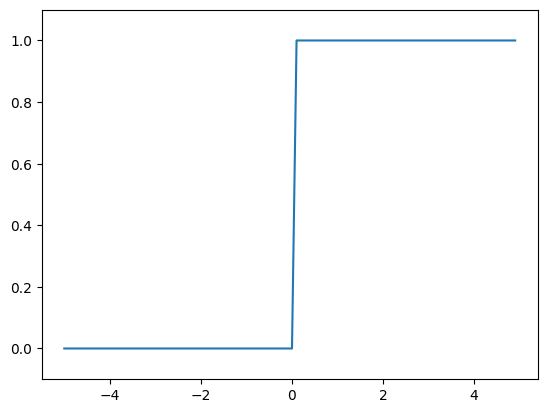

In [99]:
import numpy as np
import matplotlib.pylab as plt

def step_function(x):
    return np.array(x > 0, dtype=int)

x = np.arange(-5, 5, 0.1)
y = step_function(x)

plt.plot(x, y)
plt.ylim(-0.1, 1.1) # 指定y轴坐标范围
plt.show()

#### sigmoid函数的实现
在这个sigmoid函数中输入一个NumPy数组。sigmoid函数的实现能支持NumPy数组，秘密就在于NumPy的广播功能（1.5.5节）

[0.26894142 0.73105858 0.88079708]


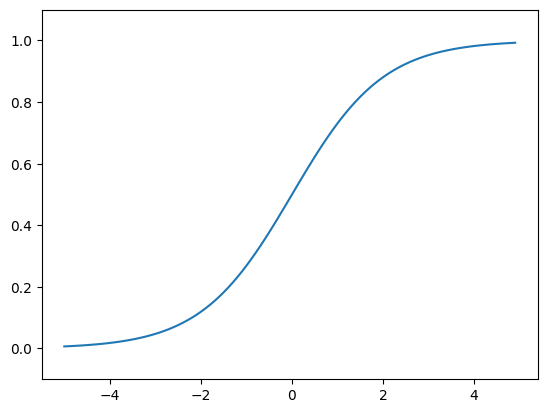

In [100]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.array([-1, 1, 2])
print(sigmoid(x))

x = np.arange(-5, 5, 0.1)
y = sigmoid(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

#### sigmoid函数和阶跃函数的比较
不同点
* “平滑性”的不同。sigmoid函数是一条平滑的曲线，输出随着输入发生连续性的变化。而阶跃函数以0为界，输出发生急剧性的变化。sigmoid函数的平滑性对神经网络的学习具有重要意义。<br>
* 另一个不同点是，相对于阶跃函数只能返回0或1，sigmoid函数可以返回0.731 ...、0.880 ...等实数（这一点和刚才的平滑性有关）。也就是说，感知机中神经元之间流动的是0或1的二元信号，而神经网络中流动的是**连续的实数值信号**。

相同点
* 从宏观视角看图，可以发现它们具有相似的形状。实际上，两者的结构均是“输入小时，输出接近0（为0）；**随着输入增大，输出向1靠近**（变成1）”。也就是说，当输入信号为重要信息时，阶跃函数和sigmoid函数都会输出较大的值；当输入信号为不重要的信息时，两者都输出较小的值。
* 还有一个共同点是，不管输入信号有多小，或者有多大，**输出信号的值都在0到1之间**。

<img src="data/neural/image5.png" style="width:40%;">

#### 非线性函数
阶跃函数和sigmoid函数还有其他共同点，就是两者均为非线性函数。sigmoid函数是一条曲线，阶跃函数是一条像阶梯一样的折线，两者都属于非线性的函数。<br>
神经网络的激活函数**必须使用非线性函数**。换句话说，激活函数不能使用线性函数。为什么不能使用线性函数呢？因为使用线性函数的话，加深神经网络的层数就没有意义了。<br>
线性函数的问题在于，不管如何加深层数，总是存在与之等效的“无隐藏层的神经网络”。<br>
考虑把线性函数h(x) = cx作为激活函数，把y(x) = h(h(h(x)))的运算对应3层神经网络A。这个运算会进行y(x) = c × c × c × x的乘法运算，但是同样的处理可以由y(x) = ax

#### ReLU函数
最近则主要使用ReLU（Rectified Linear Unit）函数<br>
ReLU函数在输入大于0时，直接输出该值；在输入小于等于0时，输出0。

$h(x)=\left\{\begin{aligned} x&&\left(x>0 \right)\\ 0&&\left(x\leqslant 0\right)\end{aligned}\right.\qquad \qquad\qquad\qquad\qquad\left(\text{3.7}\right)$



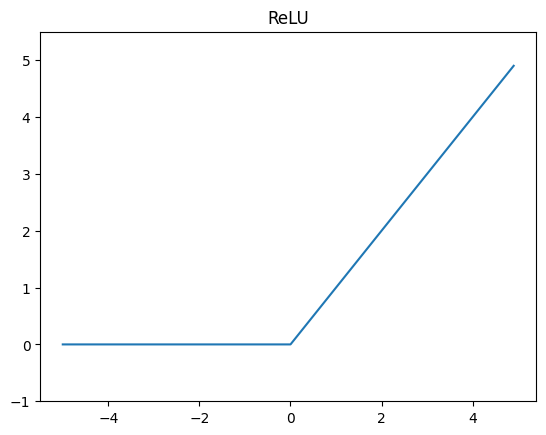

In [101]:
def relu(x):
    return np.maximum(0, x)

x = np.arange(-5, 5, 0.1)
y = relu(x)

plt.plot(x, y)
plt.ylim(-1, 5.5)
plt.title("ReLU")
plt.show()

### 多维数组的运算
掌握了NumPy多维数组的运算，就可以高效地实现神经网络。
#### 多维数组
多维数组就是“数字的集合”，数字排成一列的集合、排成长方形的集合、排成三维状或者（更加一般化的）N维状的集合都称为多维数组。<br>
* 数组的维数可以通过np.dim()函数获得
* 数组的形状可以通过实例变量shape获得
* 这里的A.shape的结果是个元组（tuple）

In [102]:
import numpy as np
A = np.array([1, 2, 3, 4])
print(A)
print(np.ndim(A))
print(A.shape)
print(A.shape[0])
print('--------------')
B = np.array([[1, 2], [3, 4], [5, 6]])
print(B)
print(np.ndim(B))
print(B.shape)

[1 2 3 4]
1
(4,)
4
--------------
[[1 2]
 [3 4]
 [5 6]]
2
(3, 2)


#### 矩阵乘法
矩阵（二维数组）的乘积

<img src="data/neural/image6.png" style="width:50%;"> <br>
<img src="data/neural/image7.png" style="width:50%;">

乘积可以通过NumPy的np.dot()函数计算（乘积也称为点积）<br>
注意的是，np.dot(A, B)和np.dot(B, A)的值可能不一样。

In [103]:
A = np.array([[1, 2], [3, 4]])
print(A.shape)
B = np.array([[5, 6], [7, 8]])
print(B.shape)
print(np.dot(A, B))
print(np.dot(B, A))

(2, 2)
(2, 2)
[[19 22]
 [43 50]]
[[23 34]
 [31 46]]


In [104]:
A = np.array([[1, 2, 3], [4, 5, 6]])
print(A.shape)
B = np.array([[1, 2], [3, 4], [5, 6]])
print(B.shape)
print(np.dot(A, B))

(2, 3)
(3, 2)
[[22 28]
 [49 64]]


2 × 3的矩阵A和3 × 2的矩阵B的乘积可按以上方式实现。<br>
矩阵A的第1维的元素个数（列数）必须和矩阵B的第0维的元素个数（行数）相等<br>
用Python计算2 × 3 的矩阵A和2 × 2的矩阵C的乘积，则会输出如下错误

In [105]:
C = np.array([[1, 2], [3, 4]])
np.dot(A, C)

ValueError: shapes (2,3) and (2,2) not aligned: 3 (dim 1) != 2 (dim 0)

错误的意思是，矩阵A的第1维和矩阵C的第0维的元素个数不一致（维度的索引从0开始）

<img src="data/neural/image8.png" style="width:50%;">

当A是二维矩阵、B是一维数组时，如图3-13所示，对应维度的元素个数要保持一致的原则依然成立。

<img src="data/neural/image9.png" style="width:50%;">


In [ ]:
A = np.array([[1, 2], [3, 4], [5, 6]])
B = np.array([7, 8])
print(np.dot(A, B))

[23 53 83]


#### 神经网络的内积
以图3-14中的简单神经网络为对象。这个神经网络省略了偏置和激活函数，只有权重。

<img src="data/neural/image10.png" style="width:50%;">

使用np.dot（多维数组的点积），可以一次性计算出Y的结果。

In [ ]:
X = np.array([1, 2])
print(X.shape)
W = np.array([[1, 3, 5], [2, 4, 6]])
print(W)
print(W.shape)
Y = np.dot(X, W)
print(Y)

(2,)
[[1 3 5]
 [2 4 6]]
(2, 3)
[ 5 11 17]


### 3层神经网络的实现
我们以图的3层神经网络为对象，实现从**输入到输出的（前向）处理**。巧妙地使用NumPy数组，可以用很少的代码完成神经网络的前向处理。

<img src="data/neural/image11.png" style="width:50%;">

#### 符号确认

在介绍神经网络中的处理之前，我们先导入$ \boldsymbol{w_{12}^{(1)}, a_{1}^{(1)}} $等符号

我们先从定义符号开始。看图中只突出显示了从输入层神经元$x_2$到后一层的神经元$ \bm{a_{1}^{(1)}} $的权重。<br>

如图所示，权重和隐藏层的神经元的右上角有一个“(1)”，它表示权重和神经元的层号（即第1层的权重、第1层的神经元）。此外，权重的右下角有两个数字，它们是后一层的神经元和前一层的神经元的索引号。比如，表示前一层的第2个神经元x2到后一层的第1个神经元的权重。权重右下角按照“后一层的索引号、前一层的索引号”的顺序排列。

<img src="data/neural/image12.png" style="width:50%;">

#### 各层间信号传递的实现

<img src="data/neural/image13.png" style="width:50%;">

图中增加了表示偏置的神经元“1”。偏置的右下角的索引号只有一个。这是因为前一层的偏置神经元（神经元“1”）只有一个A。<br>
为了确认前面的内容，现在用数学式表示。通过加权信号和偏置的和按如下方式进行计算。

$a_{1}^{(1)}=w_{11}^{(1)}x_{1}+w_{12}^{(1)}x_{2}+b_{1}^{(1)}\qquad\qquad\qquad \qquad\text{\tt(3.8)}$

使用矩阵的乘法运算，则可以将第1层的加权和表示成下面的式（3.9）。

$\bm{A}^{ \left( 1 \right)}=X \bm{W}^{ \left( 1 \right)}+ \bm{B}^{ \left( 1 \right)} \left( 3.9 \right)$

其中，$\bm{A}^{(1)},\ \bm{X},\ \bm{B}^{(1)},\ \bm{W}^{(1)}$如下所示。

$$\begin{split}\bm{A}^{(1)}&=\begin{pmatrix}a_{1}^{(1 )}&a_{2}^{(1)}&a_{3}^{(1)}\end{pmatrix},\ \bm{X}=\begin{pmatrix}x_{1}&x_{2}\end{pmatrix} ,\ \bm{B}^{(1)}=\begin{pmatrix}b_{1}^{(1 )}&b_{2}^{(1)}&b_{3}^{(1)}\end{pmatrix}\\ \bm{W}^{(1)}&=\begin{pmatrix}w_{11}^{(1)}&w_{21}^{(1)}&w_{31}^{(1)}\\ w_{12}^{(1)}&w_{22}^{(1)}&w_{32}^{(1)}\end{pmatrix}\end{split}$$


<img src="data/neural/image14.png" style="width:50%;">

隐藏层的加权和（加权信号和偏置的总和）用a表示，被激活函数转换后的信号用z表示。此外，图中h()表示激活函数，这里我们使用的是sigmoid函数。

<img src="data/neural/image15.png" style="width:50%;">

最后是第2层到输出层的信号传递（图3-20）。输出层的实现也和之前的实现基本相同。

In [ ]:
X = np.array([1, 0.5])
W1 = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
B1 = np.array([0.1, 0.2, 0.3])
print(W1.shape) # (2, 3)
print(X.shape) # (2,)
print(B1.shape) # (3,)
A1 = np.dot(X, W1) + B1

Z1 = sigmoid(A1)
print(A1)
print(Z1)
np.shape(Z1)

print('----------------')
W2 = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
B2 = np.array([0.1, 0.2])

print(Z1.shape) # (3,)
print(W2.shape) # (3, 2)
print(B2.shape) # (2,)

A2 = np.dot(Z1, W2) + B2
Z2 = sigmoid(A2)

(2, 3)
(2,)
(3,)
[0.3 0.7 1.1]
[0.57444252 0.66818777 0.75026011]
----------------
(3,)
(3, 2)
(2,)


In [ ]:
def identity_function(x):
    return x

W3 = np.array([[0.1, 0.3], [0.2, 0.4]])
B3 = np.array([0.1, 0.2])

A3 = np.dot(Z2, W3) + B3
Y = identity_function(A3) # 或者Y = A3
print(Y)

[0.31682708 0.69627909]


这里定义了identity_function()函数（也称为“恒等函数”），并将其作为输出层的激活函数。恒等函数会将输入按原样输出，因此，这个例子中没有必要特意定义identity_function()。这里这样实现只是为了和之前的流程保持统一。

<img src="data/neural/image16.png" style="width:50%;">

> 输出层所用的激活函数，要根据求解问题的性质决定。一般地，回归问题可以使用恒等函数，二元分类问题可以使用sigmoid函数，多元分类问题可以使用softmax函数。


#### 代码小结
把之前的代码实现全部整理一下 <br>
按照神经网络的实现惯例，只把权重记为大写字母W1，其他的（偏置或中间结果等）都用小写字母表示。
* init_network()函数会进行权重和偏置的初始化，并将它们保存在字典变量network中。
* forward()函数中则封装了将输入信号转换为输出信号的处理过程。
    * forward表示的是从输入到输出方向的传递处理。后面在进行神经网络的训练时，我们将介绍后向（backward，从输出到输入方向）的处理。 

In [107]:
def init_network():
    network = {}
    network['W1'] = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
    network['b1'] = np.array([0.1, 0.2, 0.3])
    network['W2'] = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
    network['b2'] = np.array([0.1, 0.2])
    network['W3'] = np.array([[0.1, 0.3], [0.2, 0.4]])
    network['b3'] = np.array([0.1, 0.2])

    return network

def forword(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = identity_function(a3)

    return y

network = init_network()
x = np.array([1, 0.5])
y = forword(network, x)
print(y)

[0.31682708 0.69627909]


### 输出层的设计
神经网络可以用在分类问题和回归问题上，不过需要根据情况改变输出层的激活函数。一般而言，回归问题用恒等函数，分类问题用softmax函数。
> 机器学习的问题大致可以分为分类问题和回归问题。分类问题是数据属于哪一个类别的问题。比如，区分图像中的人是男性还是女性的问题就是分类问题。而回归问题是根据某个输入预测一个（连续的）数值的问题。比如，根据一个人的图像预测这个人的体重的问题就是回归问题（类似“57.4kg”这样的预测）。

#### 恒等函数和softmax函数
恒等函数会将输入按原样输出，对于输入的信息，不加以任何改动地直接输出。因此，在输出层使用恒等函数时，输入信号会**原封不动地被输出**。另外，将恒等函数的处理过程用之前的神经网络图来表示的话，则如图3-21所示。

<img src="data/neural/image17.png" style="width:50%;">

分类问题中使用的softmax函数可以用下面的式（3.10）表示

$y_{k}=\frac{\exp(a_{k})}{\sum\limits_{i=1}^{n}\exp(a_{i})}\qquad\qquad\qquad \qquad\qquad\left(\text{3.10}\right)$

式（3.10）表示假设输出层共有n个神经元，计算第k个神经元的输出$y_k$。如式（3.10）所示，softmax函数的分子是输入信号$a_k$的指数函数，分母是所有输入信号的指数函数的和。<br>
用图表示softmax函数的话，softmax函数的输出通过箭头与所有的输入信号相连。这是因为输出层的各个神经元都受到所有输入信号的影响。

<img src="data/neural/image18.png" style="width:50%;">

In [111]:
a = np.array([0.3, 2.9, 4])
exp_a = np.exp(a)
print(exp_a)

sum_exp_a = np.sum(exp_a)
print(sum_exp_a)

y = exp_a / sum_exp_a
print(y)

[ 1.34985881 18.17414537 54.59815003]
74.1221542101633
[0.01821127 0.24519181 0.73659691]


In [ ]:
def softmax(a):
    exp_a = np.exp(a)
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a

    return y

#### softmax注意事项
softmax在计算机的运算有**溢出问题**。softmax函数的实现中要进行指数函数的运算，但是此时指数函数的值很容易变得非常大。比如，$e^{10}$ 的值会超过20000，$e^{100}$ 会变成一个后面有40多个0的超大值，$e^{1000}$的结果会返回一个表示无穷大的inf。如果在这些超大值之间进行除法运算，结果会出现“不确定”的情况。
> 计算机处理“数”时，数值必须在4字节或8字节的有限数据宽度内。这意味着数存在有效位数，也就是说，可以表示的数值范围是有限的。

softmax函数的实现可以像式（3.11）这样进行改进。

$\begin{aligned}y_{k}=\frac{\exp \left(a_{k}\right)}{\sum_{i=1}^{n} \exp \left(a_{i}\right)} & =\frac{\mathrm{C} \exp \left(a_{k}\right)}{\mathrm{C} \sum_{i=1}^{n} \exp \left(a_{i}\right)} \\& =\frac{\exp \left(a_{k}+\log \mathrm{C}\right)}{\sum_{i=1}^{n} \exp \left(a_{i}+\log \mathrm{C}\right)} \\& =\frac{\exp \left(a_{k}+\mathrm{C}^{\prime}\right)}{\sum_{i=1}^{n} \exp \left(a_{i}+\mathrm{C}^{\prime}\right)}\end{aligned}      \qquad\qquad\left(\text{3.10}\right)$

首先，式（3.11）在分子和分母上都乘上C这个任意的常数（因为同时对分母和分子乘以相同的常数，所以计算结果不变）。然后，把这个C移动到指数函数（exp）中，记为log C。最后，把log C替换为另一个符号 ${\rm C} ^{\prime}$。<br>
式（3.11）说明，在进行softmax的指数函数的运算时，加上（或者减去）某个常数并不会改变运算的结果。这里的 ${\rm C} ^{\prime}$ 可以使用任何值，但是为了防止溢出，一般会使用输入信号中的最大值。我们来看一个具体的例子。


In [115]:
a = np.array([1010, 1000, 990])
print(np.exp(a) / np.sum(np.exp(a)))

c = np.max(a)
print(a - c) 

print(np.exp(a - c) / np.sum(np.exp(a - c)))

[nan nan nan]
[  0 -10 -20]
[9.99954600e-01 4.53978686e-05 2.06106005e-09]


C:\Users\17363\AppData\Local\Temp\ipykernel_76920\698921258.py:2: RuntimeWarning: overflow encountered in exp
  print(np.exp(a) / np.sum(np.exp(a)))
C:\Users\17363\AppData\Local\Temp\ipykernel_76920\698921258.py:2: RuntimeWarning: invalid value encountered in divide
  print(np.exp(a) / np.sum(np.exp(a)))


In [116]:
def softmax(a):
    c = np.max(a)
    exp_a = np.exp(a - c) # 溢出对策
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a

    return y

#### softmax函数的特征
softmax函数的输出是0.0到1.0之间的实数。并且，softmax函数的输出值的总和是1。**输出总和为1是softmax函数的一个重要性质**。正因为有了这个性质，我们才可以把softmax函数的输出解释为“概率”。

比如，下面例子可以解释成y[0]的概率是0.018（1.8 %），y[1]的概率是0.245（24.5 %），y[2]的概率是0.737（73.7 %）。从概率的结果来看，可以说“因为第2个元素的概率最高，所以答案是第2个类别”。而且，还可以回答“有74%的概率是第2个类别，有25%的概率是第1个类别，有1%的概率是第0个类别”。也就是说，通过使用softmax函数，我们可以用概率的（统计的）方法处理问题。

这里需要注意的是，即便使用了softmax函数，**各个元素之间的大小关系也不会改变**。这是因为指**数函数（y = exp(x)）是单调递增函数**。实际上，例子中a的各元素的大小关系和y的各元素的大小关系并没有改变。比如，a的最大值是第2个元素，y的最大值也仍是第2个元素。

一般而言，**神经网络只把输出值最大的神经元所对应的类别作为识别结果**。并且，即便使用softmax函数，输出值最大的神经元的位置也不会变。因此，神经网络在进行分类时，输出层的softmax函数可以省略。**在实际的问题中，由于指数函数的运算需要一定的计算机运算量，因此输出层的softmax函数一般会被省略。**

> 求解机器学习问题的步骤可以分为“学习”和“推理”两个阶段。首先，在学习阶段进行模型的学习，然后，在推理阶段，用学到的模型对未知的数据进行推理（分类）。如前所述，**推理阶段一般会省略输出层的softmax函数**。在输出层使用softmax函数是因为它和神经网络的学习有关系（详细内容请参考下一章）。

In [117]:
a = np.array([0.3, 2.9, 4])
y = softmax(a)
print(y)

[0.01821127 0.24519181 0.73659691]


#### 输出层的神经元数量
输出层的神经元数量需要根据待解决的问题来决定。对于分类问题，输出层的神经元数量一般设定为类别的数量。比如，对于某个输入图像，预测是图中的数字0到9中的哪一个的问题（10类别分类问题），可以像图3-23这样，**将输出层的神经元设定为10个**。<br>
如图3-23所示，在这个例子中，输出层的神经元从上往下依次对应数字0, 1, ..., 9。此外，图中输出层的神经元的值用不同的灰度表示。这个例子中**神经元y2颜色最深，输出的值最大**。这表明这个神经网络预测的是y2对应的类别，也就是“2”。

<img src="data/neural/image19.png" style="width:50%;">


### 手写数字识别
假设学习已经全部结束，我们使用学习到的参数，先实现神经网络的“推理处理”。这个推理处理也称为神经网络的前向传播（forward propagation）。
> 和求解机器学习问题的步骤（分成学习和推理两个阶段进行）一样， 使用神经网络解决问题时，也需要首先使用训练数据（学习数据）进行权重参数的学习；进行推理时，使用刚才学习到的参数，对输入数据进行分类。

#### MNIST数据集
MNIST是机器学习领域最有名的数据集之一，被应用于从简单的实验到发表的论文研究等各种场合。实际上，在阅读图像识别或机器学习的论文时，MNIST数据集经常作为实验用的数据出现。<br>
MNIST数据集是由0到9的数字图像构成的（图3-24）。训练图像有6万张，测试图像有1万张，这些图像可以用于学习和推理。MNIST数据集的一般使用方法是，先用训练图像进行学习，再用学习到的模型度量能在多大程度上对测试图像进行正确的分类。

<img src="data/neural/image20.png" style="width:50%;">

MNIST的图像数据是28像素 × 28像素的灰度图像（1通道），各个像素 的取值在0到255之间。每个图像数据都相应地标有“7”“2”“1”等标签。<br>
本书提供了便利的Python脚本mnist.py，该脚本支持从下载MNIST数据集到将这些数据转换成NumPy数组等处理（mnist.py在dataset目录下）。使用 mnist.py时，当前目录必须是ch01、ch02、ch03、…、ch08目录中的一个。使用mnist.py中的load_mnist()函数，就可以按下述方式轻松读入MNIST数据。<br>
项目链接：https://github.com/oreilly-japan/deep-learning-from-scratch

In [9]:
# import sys, os
# sys.path.append(os.pardir)  # 这里代码和工具放在同一父文件夹下，不用加

from dataset.mnist import load_mnist

# 第一次调用会花费几分钟…… 
(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False)

print(x_train.shape)
print(t_train.shape)
print(x_test.shape)
print(t_test.shape)

(60000, 784)
(60000,)
(10000, 784)
(10000,)


load_mnist函数以“(训练图像,训练标签)，(测试图像，测试标签)”的形式返回读入的MNIST数据。此外，还可以像load_mnist(normalize=True, flatten=True, one_hot_label=False) 这样，设置3个参数。
* 第1个参数 normalize 设置是否将输入图像正规化为0.0～1.0的值。如果将该参数设置为False，则输入图像的像素会保持原来的0～255。
* 第2个参数flatten设置是否展开输入图像（变成一维数组）。如果将该参数设置为False，则输入图像为1 × 28 × 28的三维数组；若设置为True，则输入图像会保存为由784个元素构成的一维数组。
* 第3个参数one_hot_label设置是否将标签保存为onehot表示（one-hot representation）。one-hot表示是仅正确解标签为1，其余 皆为0的数组，就像[0,0,1,0,0,0,0,0,0,0]这样。当one_hot_label为False时， 只是像7、2这样简单保存正确解标签；当one_hot_label为True时，标签则 保存为one-hot表示。

> Python有pickle这个便利的功能。这个功能可以将程序运行中的对 象保存为文件。如果加载保存过的pickle文件，可以立刻复原之前 程序运行中的对象。

图像的显示使用PIL（Python Image Library）模块

In [1]:
import numpy as np
from dataset.mnist import load_mnist
from PIL import Image 
def img_show(img): 
    pil_img = Image.fromarray(np.uint8(img)) 
    pil_img.show() 

(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False) 

img = x_train[0] 
label = t_train[0] 
print(label) # 5 
print(img.shape) # (784,) 
img = img.reshape(28, 28) # 把图像的形状变成原来的尺寸 
print(img.shape) # (28, 28) 

img_show(img)

5
(784,)
(28, 28)
